E-404 HEAT EXCHANGER DESIGN - KERN METHOD

E-404 inlet temperature from E-401: 188.961 °C
E-404 inlet pressure after E-401: 48.645 bar
Heat Duty Q: 7333.10 kW
Sensible-duty estimate: 4020.52 kW
Condensation-duty remainder: 3312.58 kW
Latent-duty fraction used in HTC model: 0.452
LMTD: 56.88 K
Correction Factor Ft: 0.870
Effective Temperature Difference: 49.49 K
Tube Length L: 4.88 m
Number of Passes: 4

VELOCITY CONSTRAINTS (Section 12.7.2):
  Tube-side (high-pressure vapour): 5.0-10.0 m/s
  Shell-side (cooling water): 0.3-1.0 m/s

DESIGN RESULTS FOR DIFFERENT TUBE DIAMETERS
d_o(m)   d_i(m)   A(m²)    N_t    D_s(m)   h_t        h_s        U          ΔPt      ΔPs      V-OK  
                                           W/m²K      W/m²K      W/m²K      kPa      kPa            
--------------------------------------------------------------------------------
0.016    0.012    260.3    1064   0.815    1694.7     2805.3     569.2      150.97   30.82     ✗    
0.020    0.016    297.4    972    

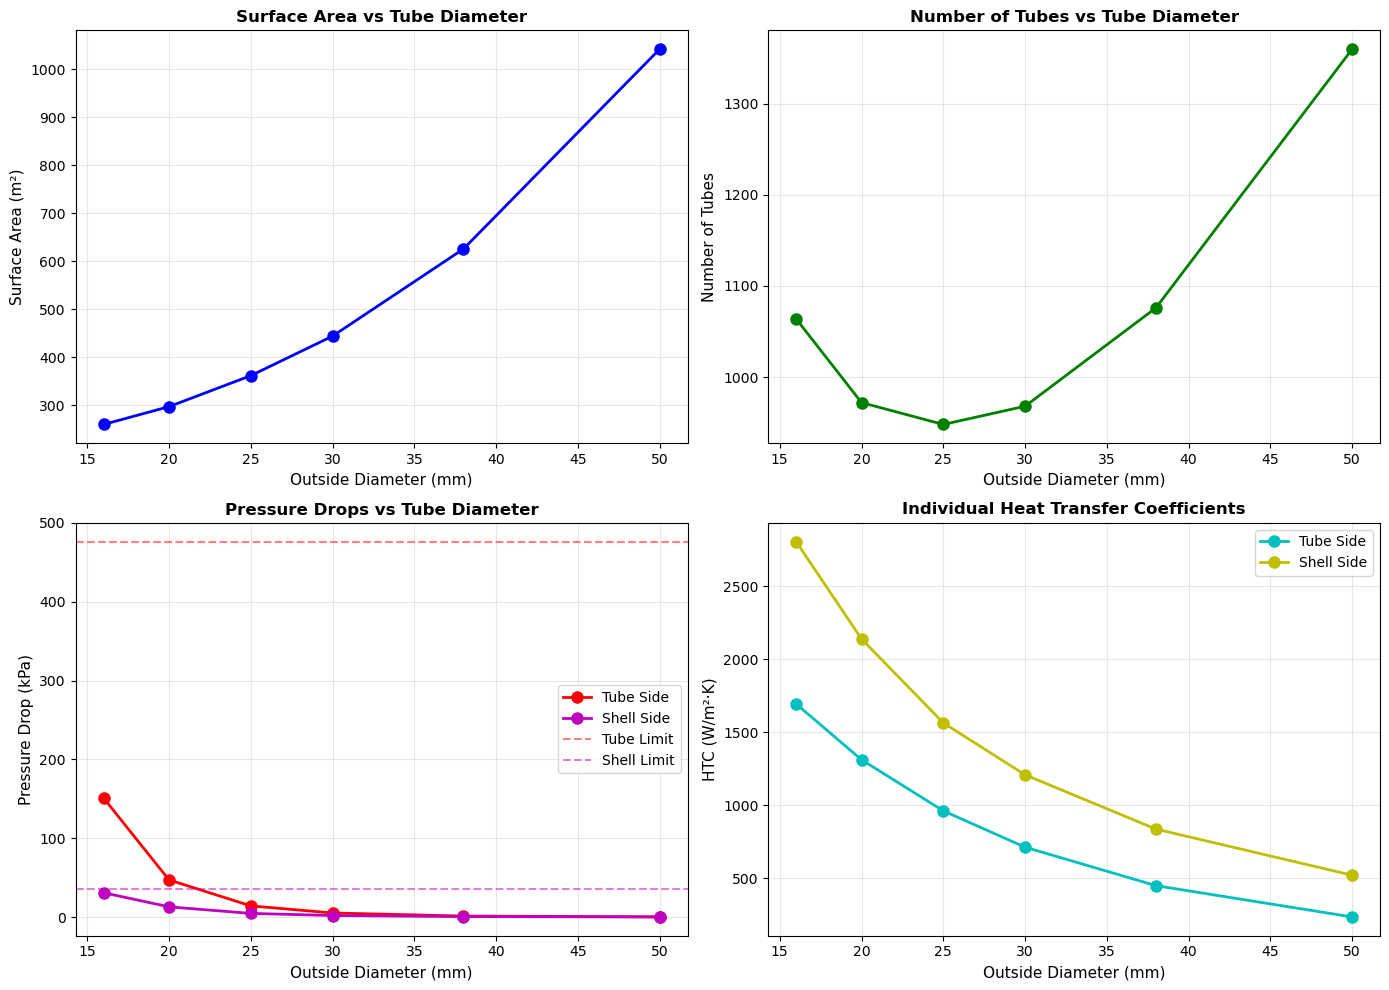


ACCEPTABLE DESIGNS (Meeting ALL Criteria):

Tube OD: 20.0 mm
  Number of tubes: 972
  Shell diameter: 960.6 mm
  Overall U: 498.2 W/m²·K
  Tube velocity: 9.68 m/s (Target: 5.0-10.0 m/s)
  Shell velocity: 0.95 m/s (Target: 0.3-1.0 m/s)
  Tube pressure drop: 47.11 kPa (Max: 476 kPa)
  Shell pressure drop: 12.96 kPa (Max: 35 kPa)

DETAILED VELOCITY ANALYSIS:

Tube OD: 16.0 mm
  Reynolds Number (Tube): 173579 (Turbulent)
  Reynolds Number (Shell): 16686
  Velocity (Tube): 15.72 m/s ✗ (Target: 5.0-10.0 m/s)
  Velocity (Shell): 1.33 m/s ✗ (Target: 0.3-1.0 m/s)
  Pressure Drop OK: Tube=YES, Shell=YES
  Overall Assessment: NOT ACCEPTABLE

Tube OD: 20.0 mm
  Reynolds Number (Tube): 142507 (Turbulent)
  Reynolds Number (Shell): 14999
  Velocity (Tube): 9.68 m/s ✓ (Target: 5.0-10.0 m/s)
  Velocity (Shell): 0.95 m/s ✓ (Target: 0.3-1.0 m/s)
  Pressure Drop OK: Tube=YES, Shell=YES
  Overall Assessment: ACCEPTABLE

Tube OD: 25.0 mm
  Reynolds Number (Tube): 111325 (Turbulent)
  Reynolds Number (Shel

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

# Implements Kern method for shell and tube heat exchanger design

# =============================================================================
# INPUT PARAMETERS
# =============================================================================

# E-404 is downstream of E-401. The process-side inlet therefore uses the
# E-401 hot-side outlet, which was calculated from the final R-402 Python outlet.
# The R-402 outlet composition is unchanged through E-401 because E-401 only
# exchanges sensible heat.

# Molecular weights [kg/kmol]
MW_values = {
    'H2': 2.01588, 'N2': 28.0134, 'CO': 28.0101, 'CO2': 44.0095,
    'CH4': 16.0425, 'H2O': 18.01528, 'C2H2': 26.0373,
    'C2H4': 28.0532, 'C2H6': 30.069, 'C6H6': 78.1118,
    'CH3OH': 32.04186
}

Cp_values = {
    'H2': 14.5, 'N2': 1.05, 'CO': 1.05, 'CO2': 0.98,
    'CH4': 2.69, 'H2O': 1.93, 'C2H2': 2.02,
    'C2H4': 2.05, 'C2H6': 2.37, 'C6H6': 1.61,
    'CH3OH': 1.73
}

# -----------------------------------------------------------------------------
# Shell side: cooling water
# -----------------------------------------------------------------------------
Q_design = 7333.1e3                 # Aspen E-404 design duty, W
T1 = 20.0                           # Cooling-water inlet temperature, °C
T2 = 30.0                           # Cooling-water outlet temperature, °C
Cp_h = 4180.0                       # Cooling-water heat capacity, J/kg/K
m_h = Q_design/(Cp_h*(T2-T1))       # Cooling-water mass flow rate, kg/s
rho_h = (998.2 + 995.7)/2           # kg/m³
mu_h = (0.001002 + 0.000798)/2      # Pa.s
k_h = (0.598 + 0.615)/2             # W/m/K
fouling_h = 0.0002                  # m².K/W

# -----------------------------------------------------------------------------
# Tube side: reactor effluent after E-401
# Composition is the final R-402 Python outlet; E-401 changes temperature only.
# -----------------------------------------------------------------------------
hot_mass_flow_kg_h = {
    'H2': 2639.9851464843246,
    'CO': 8093.463185281530,
    'CO2': 4465.339646381825,
    'CH4': 7887.074,
    'N2': 455.726,
    'H2O': 98.74402185233754,
    'CH3OH': 9423.206,
    'C2H2': 78.953,
    'C2H4': 1316.273,
    'C2H6': 5.568,
    'C6H6': 0.509,
}

m_c = sum(hot_mass_flow_kg_h.values())/3600.0
Cp_c = (
    sum(hot_mass_flow_kg_h[i]*Cp_values[i] for i in hot_mass_flow_kg_h)
    / sum(hot_mass_flow_kg_h.values())
) * 1000.0

total_kmol_h = sum(
    hot_mass_flow_kg_h[i]/MW_values[i]
    for i in hot_mass_flow_kg_h
)
MW_mix = sum(hot_mass_flow_kg_h.values())/total_kmol_h

t1 = 188.961                        # E-401 hot-side outlet / E-404 inlet, °C
t2 = 32.0                           # E-404 outlet target, °C

# R-402 Python outlet pressure minus the calculated E-401 hot-side pressure drop
P_tube_in_bar = 48.810 - 0.1647
Z = 1.015                           # Representative compressibility factor
T_mean_K = ((t1+t2)/2.0) + 273.15
rho_c = (
    P_tube_in_bar*1e5*(MW_mix/1000.0)
    /(Z*8.314462618*T_mean_K)
)

mu_c = 2.20e-5                      # Pa.s, representative process vapour
k_c = 0.080                         # W/m/K, representative process vapour
fouling_c = 0.0002                  # m².K/W

# Condensation basis.
# Aspen supplies the total exchanger duty. The sensible contribution is
# estimated from the Python-derived E-404 inlet stream and the remaining duty
# is treated as condensation duty for the effective tube-side HTC weighting.
Q_sensible = m_c*Cp_c*(t1-t2)
Q_latent = max(Q_design-Q_sensible, 0.0)
latent_fraction = min(max(Q_latent/Q_design, 0.0), 0.95)
sensible_fraction = 1.0-latent_fraction

# Approximate methanol-rich condensate properties
rho_cond = 760.0                    # kg/m³
mu_cond = 0.00045                   # Pa.s
k_cond = 0.19                       # W/m/K
rho_vap = rho_c
hfg_cond = 1100e3                   # J/kg, representative latent heat

# Tube specifications
d_o_list = [0.016, 0.020, 0.025, 0.030, 0.038, 0.050]  # Outside diameter, m
wall_thickness = 0.002              # Wall thickness, m
k_w = 16                            # Tube wall thermal conductivity, W/m·K
L = 4.88                            # Tube length, m
pitch_ratio = 1.25                  # Pitch to diameter ratio (triangular)
N_p = 4                             # Number of tube passes

# Design parameters
U_assumed = 500                     # Initial assumed overall HTC, W/m²·K
baffle_spacing_ratio = 1.0          # Baffle spacing ratio (l_B/D_s)

# Dittus-Boelter equation
heating_or_cooling = 0.3

# Allowable pressure drops
deltaP_tube_max = 0.10*(P_tube_in_bar-1.01325)*1e5   # Pa
deltaP_shell_max = 35000                      # Pa

# Velocity constraints
v_tube_min = 5.0                     # m/s, high-pressure vapour
v_tube_max = 10.0                    # m/s, high-pressure vapour
v_shell_min = 0.3                    # m/s, liquid
v_shell_max = 1.0                    # m/s, liquid

# =============================================================================
# HEAT TRANSFER CALCULATIONS
# =============================================================================

def calculate_heat_duty():
    """Use Aspen E-404 duty as the design basis"""
    return Q_design

def calculate_LMTD(T1, T2, t1, t2):
    """Calculate Log Mean Temperature Difference"""
    delta_T1 = t1 - T2
    delta_T2 = t2 - T1

    if abs(delta_T1 - delta_T2) < 1e-6:
        return delta_T1

    return abs(
        (delta_T1 - delta_T2)
        / math.log(abs(delta_T1)/abs(delta_T2))
    )

def calculate_Ft(T1, T2, t1, t2):
    """Calculate LMTD correction factor for 1-shell-pass exchanger"""
    R = abs(t1 - t2) / abs(T2 - T1)
    S = abs(T2 - T1) / abs(t1 - T1)

    if abs(R - 1) < 1e-6:
        R = 1.0001

    if abs(S) < 1e-6 or abs(1 - S) < 1e-6:
        return 0.95

    try:
        term1 = math.sqrt(R**2 + 1)
        term2 = (
            2 - S*(R + 1 - term1)
        ) / (
            2 - S*(R + 1 + term1)
        )

        if term2 <= 0 or (1 - S) <= 0 or (1 - R*S) <= 0:
            return 0.95

        numerator = term1 * math.log((1 - S)/(1 - R*S))
        denominator = (R - 1) * math.log(term2)

        if abs(denominator) < 1e-6:
            return 0.95

        Ft = numerator / denominator

        if Ft < 0.5 or Ft > 1.0:
            return 0.95

        return Ft

    except:
        return 0.95

# =============================================================================
# TUBE BUNDLE GEOMETRY
# =============================================================================

def calculate_tube_count(A_req, d_o, L):
    """Calculate number of tubes required"""
    N_t = A_req/(math.pi*d_o*L)
    N_t = int(math.ceil(N_t))

    remainder = N_t % N_p

    if remainder != 0:
        N_t += N_p - remainder

    return N_t

def calculate_bundle_diameter(N_t, d_o, pitch_ratio, N_p):
    """Calculate tube bundle diameter constants"""
    constants = {
        1: (0.319, 2.142),
        2: (0.249, 2.207),
        4: (0.175, 2.285),
        6: (0.0743, 2.499)
    }

    K1, n1 = constants.get(N_p, (0.249, 2.207))
    D_b = d_o*(N_t/K1)**(1/n1)

    return D_b

def calculate_shell_diameter(D_b):
    """Calculate shell diameter from bundle diameter"""
    if D_b < 0.3:
        clearance = 0.05
    elif D_b < 0.5:
        clearance = 0.07
    elif D_b < 1.0:
        clearance = 0.09
    else:
        clearance = 0.11

    return D_b + clearance

# =============================================================================
# TUBE SIDE CALCULATIONS
# =============================================================================

def tube_side_coefficient(d_i, N_t, N_p, m, rho, mu, k, Cp, d_o, D_b):
    """Calculate effective tube-side heat transfer coefficient"""

    A_t = (N_t/N_p)*math.pi*d_i**2/4

    u_t = m/(rho*A_t)

    Re = rho*u_t*d_i/mu

    Pr = Cp*mu/k

    if Re > 2100:
        Nu = 0.021*Re**0.8*Pr**0.33
    else:
        Nu = 3.66

    h_gas = Nu*k/d_i

    vertical_rows = max(
        1,
        round(D_b/(pitch_ratio*d_o))
    )

    film_delta_T = 10.0

    h_single = 0.725*(
        (
            rho_cond*(rho_cond-rho_vap)*9.80665
            * hfg_cond*k_cond**3
        )
        / (
            mu_cond*d_o*film_delta_T
        )
    )**0.25

    h_cond = h_single/vertical_rows**0.25

    h_t = 1/(
        sensible_fraction/h_gas
        + latent_fraction/h_cond
    )

    return h_t, Re, u_t

def tube_side_pressure_drop(N_p, L, d_i, rho, u_t, Re):
    """Calculate tube-side pressure drop"""

    if Re > 2100:
        jf = 0.079*Re**(-0.25)
    else:
        jf = 16/Re

    deltaP = (
        N_p
        * (
            8*jf*(L/d_i)
            + 2.5
        )
        * (
            rho*u_t**2/2
        )
    )

    return deltaP

# =============================================================================
# SHELL SIDE CALCULATIONS
# =============================================================================

def shell_side_equivalent_diameter(d_o, pitch_ratio):
    """Calculate shell-side equivalent diameter for triangular pitch"""

    p_t = pitch_ratio*d_o

    d_e = (
        1.10/d_o
        * (
            p_t**2
            - 0.917*d_o**2
        )
    )

    return d_e

def shell_side_coefficient(D_s, d_o, d_e, baffle_spacing_ratio, m, rho, mu, k, Cp):
    """Calculate shell-side heat transfer coefficient"""

    l_B = baffle_spacing_ratio*D_s

    p_t = pitch_ratio*d_o

    A_s = (
        (p_t-d_o)
        * D_s
        * l_B
        / p_t
    )

    u_s = m/(rho*A_s)

    Re = rho*u_s*d_e/mu

    Pr = Cp*mu/k

    jh = 0.36*Re**(-0.55)

    Nu = jh*Re*Pr**(1/3)

    h_s = Nu*k/d_e

    return h_s, Re, u_s, l_B

def shell_side_pressure_drop(D_s, d_e, L, l_B, rho, u_s, Re):
    """Calculate shell-side pressure drop"""

    if Re < 1000:
        jf = 0.44*Re**(-0.15)
    else:
        jf = 0.044*Re**(-0.15)

    Nb = L/l_B

    deltaP = (
        8*jf
        * (D_s/d_e)
        * Nb
        * (rho*u_s**2/2)
    )

    return deltaP

# =============================================================================
# OVERALL HEAT TRANSFER COEFFICIENT
# =============================================================================

def calculate_overall_U(h_t, h_s, d_o, d_i, k_w, fouling_t, fouling_s):
    """Calculate overall heat-transfer coefficient"""

    U_inv = (
        1/h_s
        + fouling_s
        + d_o*math.log(d_o/d_i)/(2*k_w)
        + (d_o*fouling_t)/d_i
        + d_o/(d_i*h_t)
    )

    return 1/U_inv

# =============================================================================
# MAIN DESIGN ITERATION
# =============================================================================

Q = calculate_heat_duty()
LMTD = calculate_LMTD(T1, T2, t1, t2)
Ft = calculate_Ft(T1, T2, t1, t2)
deltaT_m = Ft*LMTD

print("="*80)
print("E-404 HEAT EXCHANGER DESIGN - KERN METHOD")
print("="*80)

print(f"\nE-404 inlet temperature from E-401: {t1:.3f} °C")
print(f"E-404 inlet pressure after E-401: {P_tube_in_bar:.3f} bar")
print(f"Heat Duty Q: {Q/1000:.2f} kW")
print(f"Sensible-duty estimate: {Q_sensible/1000:.2f} kW")
print(f"Condensation-duty remainder: {Q_latent/1000:.2f} kW")
print(f"Latent-duty fraction used in HTC model: {latent_fraction:.3f}")
print(f"LMTD: {LMTD:.2f} K")
print(f"Correction Factor Ft: {Ft:.3f}")
print(f"Effective Temperature Difference: {deltaT_m:.2f} K")
print(f"Tube Length L: {L} m")
print(f"Number of Passes: {N_p}")

print("\n" + "="*80)
print("VELOCITY CONSTRAINTS (Section 12.7.2):")
print(f"  Tube-side (high-pressure vapour): {v_tube_min}-{v_tube_max} m/s")
print(f"  Shell-side (cooling water): {v_shell_min}-{v_shell_max} m/s")
print("="*80)

results = []

for d_o in d_o_list:

    d_i = d_o - 2*wall_thickness

    if d_i <= 0:
        print(f"Warning: Invalid tube inner diameter for d_o={d_o}. Skipping.")
        continue

    U_calc = U_assumed
    tolerance = 0.01
    max_iterations = 20

    for iteration in range(max_iterations):

        A_req = Q/(U_calc*deltaT_m)

        N_t = calculate_tube_count(A_req, d_o, L)

        D_b = calculate_bundle_diameter(N_t, d_o, pitch_ratio, N_p)
        D_s = calculate_shell_diameter(D_b)

        h_t, Re_t, u_t = tube_side_coefficient(
            d_i, N_t, N_p, m_c, rho_c, mu_c, k_c, Cp_c, d_o, D_b
        )

        deltaP_t = tube_side_pressure_drop(
            N_p, L, d_i, rho_c, u_t, Re_t
        )

        d_e = shell_side_equivalent_diameter(d_o, pitch_ratio)

        h_s, Re_s, u_s, l_B = shell_side_coefficient(
            D_s, d_o, d_e, baffle_spacing_ratio,
            m_h, rho_h, mu_h, k_h, Cp_h
        )

        deltaP_s = shell_side_pressure_drop(
            D_s, d_e, L, l_B, rho_h, u_s, Re_s
        )

        U_new = calculate_overall_U(
            h_t, h_s, d_o, d_i, k_w, fouling_c, fouling_h
        )

        if abs(U_new-U_calc)/U_calc < tolerance:
            U_calc = U_new
            break

        U_calc = U_new

    A_req = Q/(U_calc*deltaT_m)

    N_t = calculate_tube_count(A_req, d_o, L)

    D_b = calculate_bundle_diameter(N_t, d_o, pitch_ratio, N_p)
    D_s = calculate_shell_diameter(D_b)

    h_t, Re_t, u_t = tube_side_coefficient(
        d_i, N_t, N_p, m_c, rho_c, mu_c, k_c, Cp_c, d_o, D_b
    )

    deltaP_t = tube_side_pressure_drop(
        N_p, L, d_i, rho_c, u_t, Re_t
    )

    d_e = shell_side_equivalent_diameter(d_o, pitch_ratio)

    h_s, Re_s, u_s, l_B = shell_side_coefficient(
        D_s, d_o, d_e, baffle_spacing_ratio,
        m_h, rho_h, mu_h, k_h, Cp_h
    )

    deltaP_s = shell_side_pressure_drop(
        D_s, d_e, L, l_B, rho_h, u_s, Re_s
    )

    v_tube_ok = (v_tube_min <= u_t <= v_tube_max)
    v_shell_ok = (v_shell_min <= u_s <= v_shell_max)

    velocity_ok = v_tube_ok and v_shell_ok

    geometry_ok = 5 <= L/D_s <= 10

    pressure_ok = (
        deltaP_t < deltaP_tube_max
        and deltaP_s < deltaP_shell_max
    )

    results.append({
        'd_o': d_o,
        'd_i': d_i,
        'A_req': A_req,
        'N_t': N_t,
        'D_s': D_s,
        'h_t': h_t,
        'h_s': h_s,
        'U': U_calc,
        'deltaP_t': deltaP_t/1000,
        'deltaP_s': deltaP_s/1000,
        'Re_t': Re_t,
        'Re_s': Re_s,
        'u_t': u_t,
        'u_s': u_s,
        'v_tube_ok': v_tube_ok,
        'v_shell_ok': v_shell_ok,
        'velocity_ok': velocity_ok,
        'geometry_ok': geometry_ok,
        'pressure_ok': pressure_ok
    })

# Display results
print("\nDESIGN RESULTS FOR DIFFERENT TUBE DIAMETERS")
print("="*80)

print(
    f"{'d_o(m)':<8} {'d_i(m)':<8} {'A(m²)':<8} {'N_t':<6} {'D_s(m)':<8} "
    f"{'h_t':<10} {'h_s':<10} {'U':<10} {'ΔPt':<8} {'ΔPs':<8} {'V-OK':<6}"
)

print(
    f"{'':8} {'':8} {'':8} {'':6} {'':8} {'W/m²K':<10} {'W/m²K':<10} "
    f"{'W/m²K':<10} {'kPa':<8} {'kPa':<8} {'':6}"
)

print("-"*80)

for r in results:

    marker = " ✓" if r['velocity_ok'] else " ✗"

    print(
        f"{r['d_o']:<8.3f} {r['d_i']:<8.3f} {r['A_req']:<8.1f} {r['N_t']:<6} "
        f"{r['D_s']:<8.3f} {r['h_t']:<10.1f} {r['h_s']:<10.1f} {r['U']:<10.1f} "
        f"{r['deltaP_t']:<8.2f} {r['deltaP_s']:<8.2f} {marker:<6}"
    )

# Plotting
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

d_o_values = [r['d_o']*1000 for r in results]

ax1.plot(
    d_o_values,
    [r['A_req'] for r in results],
    'bo-',
    linewidth=2,
    markersize=8
)
ax1.set_xlabel('Outside Diameter (mm)', fontsize=11)
ax1.set_ylabel('Surface Area (m²)', fontsize=11)
ax1.set_title('Surface Area vs Tube Diameter', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(
    d_o_values,
    [r['N_t'] for r in results],
    'go-',
    linewidth=2,
    markersize=8
)
ax2.set_xlabel('Outside Diameter (mm)', fontsize=11)
ax2.set_ylabel('Number of Tubes', fontsize=11)
ax2.set_title('Number of Tubes vs Tube Diameter', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

ax3.plot(
    d_o_values,
    [r['deltaP_t'] for r in results],
    'ro-',
    label='Tube Side',
    linewidth=2,
    markersize=8
)
ax3.plot(
    d_o_values,
    [r['deltaP_s'] for r in results],
    'mo-',
    label='Shell Side',
    linewidth=2,
    markersize=8
)
ax3.axhline(
    y=deltaP_tube_max/1000,
    color='r',
    linestyle='--',
    alpha=0.5,
    label='Tube Limit'
)
ax3.axhline(
    y=deltaP_shell_max/1000,
    color='m',
    linestyle='--',
    alpha=0.5,
    label='Shell Limit'
)
ax3.set_xlabel('Outside Diameter (mm)', fontsize=11)
ax3.set_ylabel('Pressure Drop (kPa)', fontsize=11)
ax3.set_title('Pressure Drops vs Tube Diameter', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4.plot(
    d_o_values,
    [r['h_t'] for r in results],
    'co-',
    label='Tube Side',
    linewidth=2,
    markersize=8
)
ax4.plot(
    d_o_values,
    [r['h_s'] for r in results],
    'yo-',
    label='Shell Side',
    linewidth=2,
    markersize=8
)
ax4.set_xlabel('Outside Diameter (mm)', fontsize=11)
ax4.set_ylabel('HTC (W/m²·K)', fontsize=11)
ax4.set_title('Individual Heat Transfer Coefficients', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

acceptable_designs = [
    r for r in results
    if r['velocity_ok']
    and r['pressure_ok']
    and r['geometry_ok']
]

if acceptable_designs:

    print("\n" + "="*80)
    print("ACCEPTABLE DESIGNS (Meeting ALL Criteria):")
    print("="*80)

    for r in acceptable_designs:

        print(f"\nTube OD: {r['d_o']*1000:.1f} mm")
        print(f"  Number of tubes: {r['N_t']}")
        print(f"  Shell diameter: {r['D_s']*1000:.1f} mm")
        print(f"  Overall U: {r['U']:.1f} W/m²·K")
        print(
            f"  Tube velocity: {r['u_t']:.2f} m/s "
            f"(Target: {v_tube_min}-{v_tube_max} m/s)"
        )
        print(
            f"  Shell velocity: {r['u_s']:.2f} m/s "
            f"(Target: {v_shell_min}-{v_shell_max} m/s)"
        )
        print(
            f"  Tube pressure drop: {r['deltaP_t']:.2f} kPa "
            f"(Max: {deltaP_tube_max/1000:.0f} kPa)"
        )
        print(
            f"  Shell pressure drop: {r['deltaP_s']:.2f} kPa "
            f"(Max: {deltaP_shell_max/1000:.0f} kPa)"
        )

else:

    print("\n" + "="*80)
    print("WARNING: No designs meet ALL criteria!")
    print("Consider:")
    print("  - Adjusting tube length")
    print("  - Changing number of tube passes")
    print("  - Using different tube diameters")
    print("  - Adjusting baffle spacing")
    print("="*80)

# Additional analysis
print("\n" + "="*80)
print("DETAILED VELOCITY ANALYSIS:")
print("="*80)

for i, r in enumerate(results):

    print(f"\nTube OD: {r['d_o']*1000:.1f} mm")

    print(
        f"  Reynolds Number (Tube): {r['Re_t']:.0f} "
        f"({'Turbulent' if r['Re_t'] > 4000 else 'Transitional' if r['Re_t'] > 2100 else 'Laminar'})"
    )

    print(f"  Reynolds Number (Shell): {r['Re_s']:.0f}")

    print(
        f"  Velocity (Tube): {r['u_t']:.2f} m/s "
        f"{'✓' if r['v_tube_ok'] else '✗'} "
        f"(Target: {v_tube_min}-{v_tube_max} m/s)"
    )

    print(
        f"  Velocity (Shell): {r['u_s']:.2f} m/s "
        f"{'✓' if r['v_shell_ok'] else '✗'} "
        f"(Target: {v_shell_min}-{v_shell_max} m/s)"
    )

    print(
        f"  Pressure Drop OK: "
        f"Tube={'YES' if r['deltaP_t'] < deltaP_tube_max/1000 else 'NO'}, "
        f"Shell={'YES' if r['deltaP_s'] < deltaP_shell_max/1000 else 'NO'}"
    )

    print(
        f"  Overall Assessment: "
        f"{'ACCEPTABLE' if r['velocity_ok'] and r['pressure_ok'] and r['geometry_ok'] else 'NOT ACCEPTABLE'}"
    )

if acceptable_designs:
    selected = acceptable_designs[0]
    A_inst = selected['N_t']*math.pi*selected['d_o']*L

    print("\n" + "="*80)
    print("SELECTED E-404 DESIGN")
    print("="*80)
    print(f"Tube OD: {selected['d_o']*1000:.1f} mm")
    print(f"Tube ID: {selected['d_i']*1000:.1f} mm")
    print(f"Number of tubes: {selected['N_t']}")
    print(f"Tube length: {L:.2f} m")
    print(f"Tube passes: {N_p}")
    print(f"Shell diameter: {selected['D_s']:.3f} m")
    print(f"Required heat-transfer area: {selected['A_req']:.2f} m²")
    print(f"Installed heat-transfer area: {A_inst:.2f} m²")
    print(f"Tube-side h: {selected['h_t']:.1f} W/m².K")
    print(f"Shell-side h: {selected['h_s']:.1f} W/m².K")
    print(f"Overall U: {selected['U']:.1f} W/m².K")
    print(f"Tube-side velocity: {selected['u_t']:.2f} m/s")
    print(f"Shell-side velocity: {selected['u_s']:.2f} m/s")
    print(f"Tube-side Reynolds number: {selected['Re_t']:.0f}")
    print(f"Shell-side Reynolds number: {selected['Re_s']:.0f}")
    print(f"Tube-side pressure drop: {selected['deltaP_t']:.2f} kPa")
    print(f"Shell-side pressure drop: {selected['deltaP_s']:.2f} kPa")
    print(f"LMTD: {LMTD:.2f} K")
    print(f"Ft: {Ft:.3f}")

print("\n" + "="*80)
print("DESIGN COMPLETE")
print("="*80)
